In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter
import sys, os

sys.path.append(os.path.abspath('..'))
from src.preprocessing import detrend_light_curve

df_flux_data = pd.read_csv("../data/processed/clean_flux.csv")
X = df_flux_data.drop(columns=['id', 'class']).values
y = df_flux_data['class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply Detrending (Removing the stellar noise)
print("Applying Savitzky-Golay detrending... (This will take a minute)")
X_train = np.array([detrend_light_curve(row) for row in X_train])
X_test = np.array([detrend_light_curve(row) for row in X_test])

# Feature Scaling (Z-Score Normalization)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Conversion to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Create DataLoader
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

print("DataLoaders are ready with Detrended and Scaled data.")

Applying Savitzky-Golay detrending... (This will take a minute)
DataLoaders are ready with Detrended and Scaled data.


### Detrending Effects on Model Performance (Before vs After)

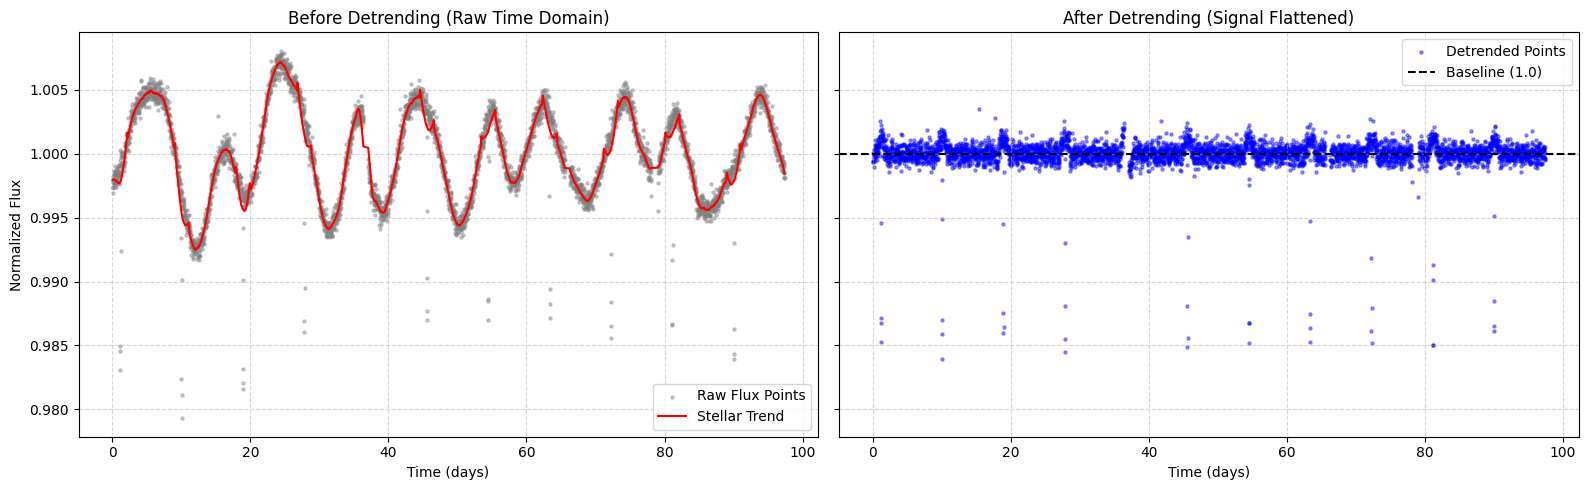

In [2]:
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

clean_flux = pd.read_csv("../data/processed/clean_flux.csv")
clean_time = pd.read_csv("../data/processed/clean_time.csv")

idx = clean_flux[clean_flux['class'] == 1].index[0]
raw_flux = clean_flux.drop(columns=['id', 'class']).iloc[idx].values
time_vals = clean_time.drop(columns=['id', 'class']).iloc[idx].values

trend = savgol_filter(raw_flux, window_length=101, polyorder=3)
detrended_flux = (raw_flux - trend) + 1.0

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)


# Graph 1: Raw data with a trend
axes[0].scatter(time_vals, raw_flux, s=5, color='gray', alpha=0.4, label='Raw Flux Points')
axes[0].plot(time_vals, trend, color='red', linewidth=1.5, label='Stellar Trend')
axes[0].set_title('Before Detrending (Raw Time Domain)')
axes[0].set_xlabel('Time (days)')
axes[0].set_ylabel('Normalized Flux')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Graph 2: Cleared data
axes[1].scatter(time_vals, detrended_flux, s=5, color='blue', alpha=0.4, label='Detrended Points')
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='Baseline (1.0)')
axes[1].set_title('After Detrending (Signal Flattened)')
axes[1].set_xlabel('Time (days)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

### Model version 4 

In [3]:
class ExoplanetCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Layer 1
            nn.Conv1d(1, 16, kernel_size=21, padding=10),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Layer 2
            nn.Conv1d(16, 32, kernel_size=11, padding=5),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Layer 3 
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(32),  

            nn.Flatten(),
            nn.Linear(64 * 32, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.net(x)


# Training

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = ExoplanetCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

n_neg, n_pos = (y_train == 0).sum(), (y_train == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

epochs = 30
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device).view(-1, 1)

        optimizer.zero_grad()         
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()              
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1:02d}/{epochs} — loss: {running_loss/len(train_loader):.4f}")

print("Training finished.")

Device: cuda
Epoch 01/30 — loss: 0.6133
Epoch 02/30 — loss: 0.5931
Epoch 03/30 — loss: 0.5807
Epoch 04/30 — loss: 0.5668
Epoch 05/30 — loss: 0.5574
Epoch 06/30 — loss: 0.5578
Epoch 07/30 — loss: 0.5586
Epoch 08/30 — loss: 0.5555
Epoch 09/30 — loss: 0.5372
Epoch 10/30 — loss: 0.5283
Epoch 11/30 — loss: 0.5306
Epoch 12/30 — loss: 0.5345
Epoch 13/30 — loss: 0.5314
Epoch 14/30 — loss: 0.5189
Epoch 15/30 — loss: 0.5200
Epoch 16/30 — loss: 0.5231
Epoch 17/30 — loss: 0.5187
Epoch 18/30 — loss: 0.5178
Epoch 19/30 — loss: 0.5196
Epoch 20/30 — loss: 0.5134
Epoch 21/30 — loss: 0.5104
Epoch 22/30 — loss: 0.5045
Epoch 23/30 — loss: 0.4986
Epoch 24/30 — loss: 0.4989
Epoch 25/30 — loss: 0.5011
Epoch 26/30 — loss: 0.5016
Epoch 27/30 — loss: 0.4799
Epoch 28/30 — loss: 0.4897
Epoch 29/30 — loss: 0.4895
Epoch 30/30 — loss: 0.4813
Training finished.


# Evaluation Score

Evaluating on test set...

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.51      0.63       600
         1.0       0.64      0.91      0.75       580

    accuracy                           0.70      1180
   macro avg       0.75      0.71      0.69      1180
weighted avg       0.75      0.70      0.69      1180



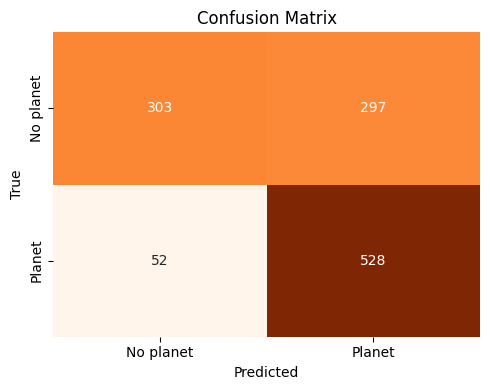

In [6]:
model.eval()
all_preds, all_targets = [], []

print("Evaluating on test set...")
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        logits = model(batch_X.to(device))
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        preds = (probs >= 0.5).astype(float)   
        all_preds.extend(preds)
        all_targets.extend(batch_y.numpy())

print("\nClassification Report:")
print(classification_report(all_targets, all_preds, zero_division=0))

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['No planet', 'Planet'],
            yticklabels=['No planet', 'Planet'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Save Model weights

In [8]:
import joblib

os.makedirs('../models', exist_ok=True)
torch.save(model.state_dict(), '../models/cnn_weights.pth')

joblib.dump(scaler, '../models/cnn_scaler.pkl')

['../models/cnn_scaler.pkl']